### Data Selection, Importation to Jupyter, Sample Comparison

My intention with this portion of this Jupyter notebook is to do some deep dives into the Natality dataset and ensure that I can do some relatively good data science here. 
Inside Google Big Query, I made a small 1M row sample of the CDC's Natality dataset. Here I will some some quick Ad Hoc cleaning, but more importantly I want to ensure that the sample that I made randomly is accurately representative of the entire 137M rows of data in the original. 

In [1]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "capstone-498819"
client = bigquery.Client(project=PROJECT_ID)

In [2]:
query = """
SELECT *
FROM `capstone-498819.Capstone_data.natality_sample`
"""
# This is a < 1% sample of the CDC "natality" dataset from Big Query Public Data.
df = client.query(query).to_dataframe()

df.head()

,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,...,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2005,2005,9,<NA>,3,None,True,<NA>,7.513354,1,...,False,<NA>,45,2,0,2,3,1,36,1
1,2005,2005,2,<NA>,6,None,True,<NA>,5.269048,1,...,False,<NA>,41,2,0,6,3,1,34,1
2,2005,2005,2,<NA>,3,None,False,<NA>,5.787134,1,...,<NA>,<NA>,41,0,0,0,1,<NA>,26,1
3,2005,2005,8,<NA>,2,None,False,<NA>,8.126239,1,...,<NA>,<NA>,6,0,0,2,1,<NA>,40,1
4,2005,2005,10,<NA>,3,None,False,<NA>,6.040666,1,...,<NA>,<NA>,99,0,0,1,1,1,22,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 31 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   source_year             1000000 non-null  Int64  
 1   year                    1000000 non-null  Int64  
 2   month                   1000000 non-null  Int64  
 3   day                     410542 non-null   Int64  
 4   wday                    589458 non-null   Int64  
 5   state                   876754 non-null   object 
 6   is_male                 1000000 non-null  boolean
 7   child_race              817471 non-null   Int64  
 8   weight_pounds           998455 non-null   float64
 9   plurality               973433 non-null   Int64  
 10  apgar_1min              682345 non-null   Int64  
 11  apgar_5min              842422 non-null   Int64  
 12  mother_residence_state  876743 non-null   object 
 13  mother_race             928520 non-null   Int64  
 14  mot

<Axes: >

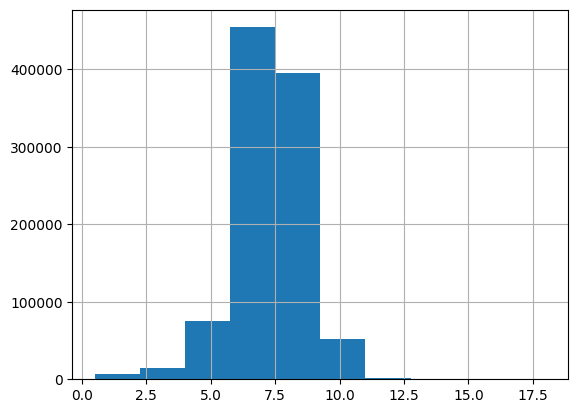

In [3]:
df.info()

df.describe()

df['weight_pounds'].hist()

In [4]:
if (df["source_year"] != df["year"]).sum() == 0:
    df = df.drop(columns=["source_year"])

In [5]:
print(df["day"].min(), df["day"].max())
print(df["wday"].min(), df["wday"].max())

1 99
1 7


In [6]:
df["day"] = df["day"].replace(99, pd.NA)

In [7]:
df["day"].max()

np.int64(31)

In [8]:
print(df["state"].value_counts(dropna=False).sort_index())
# Turns out that 2005-2008 do not include ANY state/geographical data :-(

state
AK        2335
AL       14229
AR        7700
AZ       13218
CA      100421
CO       13356
CT        9710
DC        3780
DE        2157
FL       40622
GA       22381
HI        4068
IA        9910
ID        4137
IL       43777
IN       19361
KS        9014
KY       12721
LA       17337
MA       18854
MD       14776
ME        3858
MI       34306
MN       15479
MO       19030
MS        9645
MT        2922
NC       23409
ND        2191
NE        6169
NH        3555
NJ       24341
NM        5458
NV        4668
NY       62844
OH       37501
OK       11382
OR       10209
PA       35203
RI        3348
SC       12281
SD        2474
TN       18194
TX       72417
UT        9293
VA       20547
VT        1811
WA       16090
WI       16872
WV        5835
WY        1558
None    123246
Name: count, dtype: int64


In [9]:
print(df["mother_residence_state"].value_counts(dropna=False).sort_index())

mother_residence_state
AK           2360
AL          14368
AR           7976
AZ          13271
CA         100379
CC              2
CO          13287
CT           9744
Canada         28
DC           1967
DE           2093
FL          40633
Foreign       112
GA          22172
GU              3
HI           4062
IA           9830
ID           4235
IL          44513
IN          19398
KS           9299
KY          12936
LA          17320
MA          18532
MD          15864
ME           3975
MI          34608
MN          15416
MO          18487
MS           9863
MT           2962
MX             80
Mexico        950
NC          23266
ND           1991
NE           6077
NH           3620
NJ          25014
NM           5562
NV           4700
NY          62525
OH          37322
OK          11632
OR           9901
PA          35079
PR              7
RI           3190
SC          12745
SD           2464
TN          17079
TX          71152
UT           9069
VA          21050
VI              8
VT   

In [10]:
(
    df["state"].fillna("MISSING")
    !=
    df["mother_residence_state"].fillna("MISSING")
).sum()

np.int64(22217)

In [11]:
mask = (
    df["mother_residence_state"].isna()
    &
    df["state"].notna()
)

df.loc[mask, "mother_residence_state"] = df.loc[mask, "state"]

In [12]:
(
    df["state"].isna()
    &
    df["mother_residence_state"].isna()
).sum()

np.int64(123246)

In [13]:
df.loc[
    df["state"].isna()
    &
    df["mother_residence_state"].isna(),
    "year"
].value_counts().sort_index()

year
2005    30234
2006    31107
2007    30982
2008    30923
Name: count, dtype: Int64

In [14]:
df.loc[
    df["state"].isna()
    &
    df["mother_residence_state"].isna(),
    ["year", "month"]
]

,year,month
0,2005,9
1,2005,2
2,2005,2
3,2005,8
4,2005,10
...,...,...
123241,2008,11
123242,2008,1
123243,2008,11
123244,2008,5


In [23]:
df = df.rename(columns={
    "day": "day_of_month",
    "wday": "day_of_week"
})

At this point I am going to make some notes. Some of the work I did here you can see for yourself, or I did it quickly behind the scenes to keep you from being bored. 

In [17]:
cleanup_notes = []

cleanup_notes.append(
    "Dropped source_year because it was identical to year across all 1,000,000 rows."
)

cleanup_notes.append(
    "Investigated day and wday columns. Determined they represent different concepts, not duplicate information."
)

cleanup_notes.append(
    "Retained day (day of month, values 1-31) and wday (day of week, values 1-7)."
)

cleanup_notes.append(
    "Found a schema change in the source data: day is populated for years 1969-1988 and wday is populated for years 1989+."
)

cleanup_notes.append(
    "Replaced day=99 with NA. The value occurred only 26 times in records from 1969-1986 and was determined to be a legacy missing-value code."
)

In [18]:
cleanup_notes.append(
    "Imputed 11 missing mother_residence_state values using state when state was available."
)

cleanup_notes.append(
    "Identified 123,246 records where both state and mother_residence_state are missing. Missingness is concentrated entirely in years 2005-2008, suggesting a source-data issue rather than random missing values."
)

In [19]:
cleanup_notes.append(
    "Verified against the original BigQuery natality dataset that state and mother_residence_state are unavailable for all records in years 2005-2008. Missing values were retained as NULL because the information does not exist in the source data."
)

In [20]:
data_dictionary = {
    "day": {
        "meaning": "Day of month",
        "years_available": "1969-1988",
        "cleanup": "Converted 99 to NA"
    }
}

In [21]:
cleanup_notes.append(
    "Renamed day to day_of_month and wday to day_of_week for clarity. Variables represent different temporal concepts and were retained separately."
)

### Comparison with the original 137M Rows. 

I am going to make some quick queries on the original CDC data in Big Query to make sure that the 1M rows I made will be prove an accurate enough sample for any data science or other comparative stats I might do.

In [25]:
query_full = """
WITH yearly AS (
  SELECT
    year,
    COUNT(*) AS births
  FROM `bigquery-public-data.samples.natality`
  GROUP BY year
),

growth AS (
  SELECT
    year,
    births,
    LAG(births) OVER (ORDER BY year) AS prior_year_births
  FROM yearly
)

SELECT
  year,
  births,
  prior_year_births,
  SAFE_DIVIDE(births - prior_year_births, prior_year_births) * 100 AS pct_growth
FROM growth
ORDER BY year
"""

full_growth = client.query(query_full).to_dataframe()
full_growth.head()

,year,births,prior_year_births,pct_growth
0,1969,1800103,<NA>,NaN
1,1970,1868900,1800103,3.821837
2,1971,1781774,1868900,-4.661887
3,1972,1749402,1781774,-1.816841
4,1973,1839736,1749402,5.163707


In [26]:
query_sample = """
WITH yearly AS (
  SELECT
    year,
    COUNT(*) AS births
  FROM `capstone-498819.Capstone_data.natality_sample`
  GROUP BY year
),

growth AS (
  SELECT
    year,
    births,
    LAG(births) OVER (ORDER BY year) AS prior_year_births
  FROM yearly
)

SELECT
  year,
  births,
  prior_year_births,
  SAFE_DIVIDE(births - prior_year_births, prior_year_births) * 100 AS pct_growth
FROM growth
ORDER BY year
"""

sample_growth = client.query(query_sample).to_dataframe()
sample_growth.head()

,year,births,prior_year_births,pct_growth
0,1969,13040,<NA>,NaN
1,1970,13527,13040,3.734663
2,1971,12780,13527,-5.522289
3,1972,12580,12780,-1.564945
4,1973,13422,12580,6.693164


In [27]:
comparison = full_growth.merge(
    sample_growth,
    on="year",
    suffixes=("_full", "_sample")
)

comparison["growth_diff_points"] = (
    comparison["pct_growth_sample"] - comparison["pct_growth_full"]
)

comparison.head()

,year,births_full,prior_year_births_full,pct_growth_full,births_sample,prior_year_births_sample,pct_growth_sample,growth_diff_points
0,1969,1800103,<NA>,NaN,13040,<NA>,NaN,NaN
1,1970,1868900,1800103,3.821837,13527,13040,3.734663,-0.087174
2,1971,1781774,1868900,-4.661887,12780,13527,-5.522289,-0.860402
3,1972,1749402,1781774,-1.816841,12580,12780,-1.564945,0.251896
4,1973,1839736,1749402,5.163707,13422,12580,6.693164,1.529456


In [28]:
comparison.sort_values(
    "growth_diff_points",
    key=lambda s: s.abs(),
    ascending=False
).head(10)

,year,births_full,prior_year_births_full,pct_growth_full,births_sample,prior_year_births_sample,pct_growth_sample,growth_diff_points
38,2007,4324008,4273225,1.188400,30982,31107,-0.401839,-1.590239
10,1979,3184421,2865686,11.122468,23256,20635,12.701720,1.579253
4,1973,1839736,1749402,5.163707,13422,12580,6.693164,1.529456
39,2008,4255156,4324008,-1.592319,30923,30982,-0.190433,1.401886
15,1984,3360871,3337883,0.688700,24190,24360,-0.697865,-1.386565
31,2000,4063823,3963465,2.532077,29522,28412,3.906800,1.374723
14,1983,3337883,3376813,-1.152862,24360,24328,0.131536,1.284398
18,1987,3813216,3760695,1.396577,27748,27033,2.644915,1.248339
8,1977,2772206,2463852,12.515119,20171,18119,11.325128,-1.189990
34,2003,4096092,4027376,1.706223,29512,29344,0.572519,-1.133704


In [29]:
comparison

,year,births_full,prior_year_births_full,pct_growth_full,births_sample,prior_year_births_sample,pct_growth_sample,growth_diff_points
0,1969,1800103,<NA>,NaN,13040,<NA>,NaN,NaN
1,1970,1868900,1800103,3.821837,13527,13040,3.734663,-0.087174
2,1971,1781774,1868900,-4.661887,12780,13527,-5.522289,-0.860402
3,1972,1749402,1781774,-1.816841,12580,12780,-1.564945,0.251896
4,1973,1839736,1749402,5.163707,13422,12580,6.693164,1.529456
5,1974,2029150,1839736,10.295716,14936,13422,11.279988,0.984272
6,1975,2232406,2029150,10.016805,16298,14936,9.118907,-0.897898
7,1976,2463852,2232406,10.367559,18119,16298,11.173150,0.805591
8,1977,2772206,2463852,12.515119,20171,18119,11.325128,-1.189990
9,1978,2865686,2772206,3.372044,20635,20171,2.300332,-1.071712


In [30]:
comparison["abs_growth_diff"] = (
    comparison["growth_diff_points"].abs()
)

comparison["abs_growth_diff"].mean()

np.float64(0.8145800539060557)

In [31]:
comparison["abs_growth_diff"].max()

1.5902386763457392

In [32]:
comparison["abs_growth_diff"].max()

1.5902386763457392

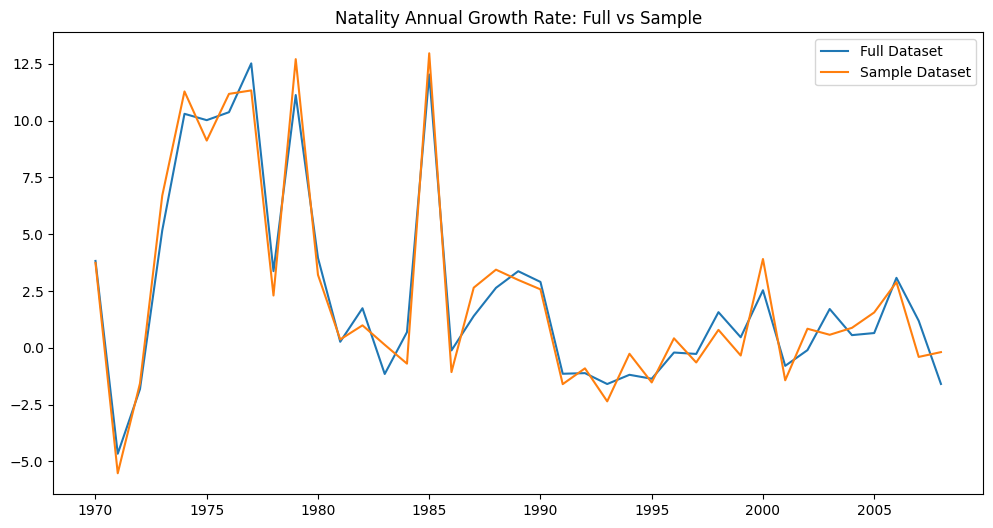

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    comparison["year"],
    comparison["pct_growth_full"],
    label="Full Dataset"
)

plt.plot(
    comparison["year"],
    comparison["pct_growth_sample"],
    label="Sample Dataset"
)

plt.legend()
plt.title("Natality Annual Growth Rate: Full vs Sample")
plt.show()

In [34]:
cleanup_notes.append(
    "Validated natality_sample against the full 137M-row natality dataset. Annual birth growth rates differed by an average of 0.82 percentage points and at most 1.59 percentage points, indicating that the sample preserves population-level temporal trends."
)

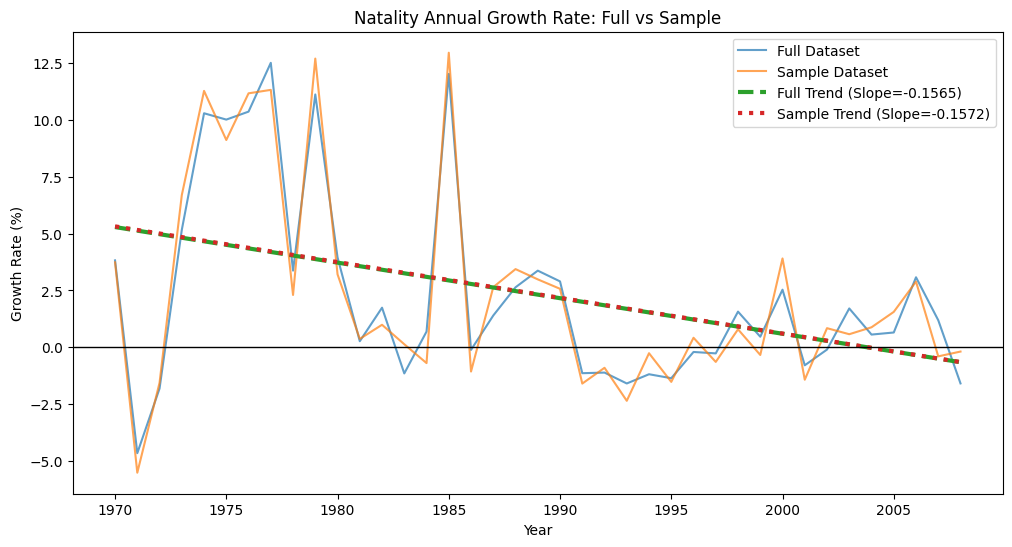

Full slope:   -0.156485
Sample slope: -0.157195


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Remove first row because growth rate is NaN
plot_df = comparison.dropna(subset=["pct_growth_full", "pct_growth_sample"])

x = plot_df["year"]

y_full = plot_df["pct_growth_full"]
y_sample = plot_df["pct_growth_sample"]

# Fit regression lines
full_coef = np.polyfit(x, y_full, 1)
sample_coef = np.polyfit(x, y_sample, 1)

full_trend = np.poly1d(full_coef)
sample_trend = np.poly1d(sample_coef)

plt.figure(figsize=(12,6))

# Original series
plt.plot(
    x,
    y_full,
    label="Full Dataset",
    alpha=0.7
)

plt.plot(
    x,
    y_sample,
    label="Sample Dataset",
    alpha=0.7
)

# Trend lines
plt.plot(
    x,
    full_trend(x),
    linestyle="--",
    linewidth=3,
    label=f"Full Trend (Slope={full_coef[0]:.4f})"
)

plt.plot(
    x,
    sample_trend(x),
    linestyle=":",
    linewidth=3,
    label=f"Sample Trend (Slope={sample_coef[0]:.4f})"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Natality Annual Growth Rate: Full vs Sample")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.show()

print(f"Full slope:   {full_coef[0]:.6f}")
print(f"Sample slope: {sample_coef[0]:.6f}")

In [37]:
query_full_age = """
SELECT
    year,
    AVG(mother_age) AS avg_mother_age
FROM `bigquery-public-data.samples.natality`
GROUP BY year
ORDER BY year
"""

full_age = client.query(query_full_age).to_dataframe()

In [38]:
query_sample_age = """
SELECT
    year,
    AVG(mother_age) AS avg_mother_age
FROM `capstone-498819.Capstone_data.natality_sample`
GROUP BY year
ORDER BY year
"""

sample_age = client.query(query_sample_age).to_dataframe()

In [39]:
age_comparison = full_age.merge(
    sample_age,
    on="year",
    suffixes=("_full", "_sample")
)

age_comparison.head()

,year,avg_mother_age_full,avg_mother_age_sample
0,1969,24.736761,24.753144
1,1970,24.614868,24.668219
2,1971,24.559934,24.523239
3,1972,24.440839,24.447059
4,1973,24.414364,24.376620


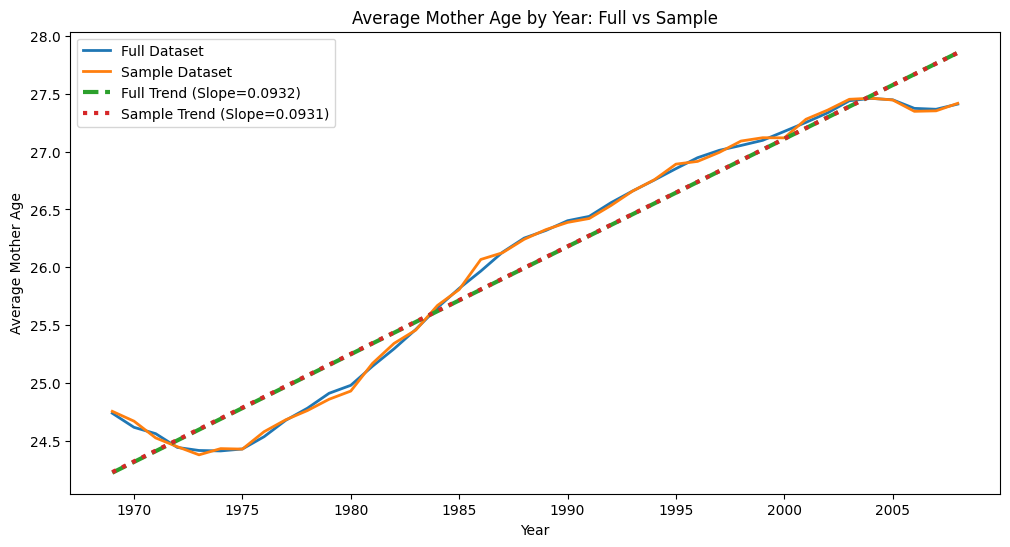

Full slope:   0.093199
Sample slope: 0.093061


In [40]:
import numpy as np
import matplotlib.pyplot as plt

x = age_comparison["year"]

y_full = age_comparison["avg_mother_age_full"]
y_sample = age_comparison["avg_mother_age_sample"]

# Fit regression lines
full_coef = np.polyfit(x, y_full, 1)
sample_coef = np.polyfit(x, y_sample, 1)

full_trend = np.poly1d(full_coef)
sample_trend = np.poly1d(sample_coef)

plt.figure(figsize=(12,6))

# Actual series
plt.plot(
    x,
    y_full,
    label="Full Dataset",
    linewidth=2
)

plt.plot(
    x,
    y_sample,
    label="Sample Dataset",
    linewidth=2
)

# Trend lines
plt.plot(
    x,
    full_trend(x),
    "--",
    linewidth=3,
    label=f"Full Trend (Slope={full_coef[0]:.4f})"
)

plt.plot(
    x,
    sample_trend(x),
    ":",
    linewidth=3,
    label=f"Sample Trend (Slope={sample_coef[0]:.4f})"
)

plt.title("Average Mother Age by Year: Full vs Sample")
plt.xlabel("Year")
plt.ylabel("Average Mother Age")
plt.legend()

plt.show()

print(f"Full slope:   {full_coef[0]:.6f}")
print(f"Sample slope: {sample_coef[0]:.6f}")

In [41]:
age_comparison["difference"] = (
    age_comparison["avg_mother_age_sample"]
    - age_comparison["avg_mother_age_full"]
)

print(
    "Mean Absolute Difference:",
    age_comparison["difference"].abs().mean()
)

Mean Absolute Difference: 0.02365206146677403


In [42]:
query_full_weight = """
SELECT
    year,
    AVG(weight_pounds) AS avg_weight
FROM `bigquery-public-data.samples.natality`
WHERE weight_pounds IS NOT NULL
GROUP BY year
ORDER BY year
"""

full_weight = client.query(query_full_weight).to_dataframe()

In [43]:
query_sample_weight = """
SELECT
    year,
    AVG(weight_pounds) AS avg_weight
FROM `capstone-498819.Capstone_data.natality_sample`
WHERE weight_pounds IS NOT NULL
GROUP BY year
ORDER BY year
"""

sample_weight = client.query(query_sample_weight).to_dataframe()

In [44]:
weight_comparison = full_weight.merge(
    sample_weight,
    on="year",
    suffixes=("_full", "_sample")
)

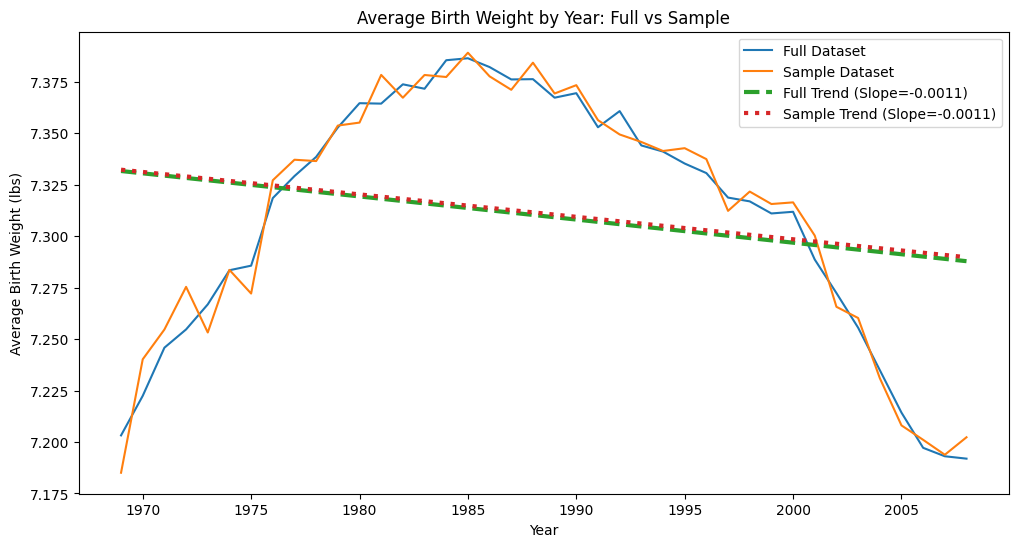

Full slope:   -0.001123
Sample slope: -0.001090


In [45]:
import numpy as np
import matplotlib.pyplot as plt

x = weight_comparison["year"]

y_full = weight_comparison["avg_weight_full"]
y_sample = weight_comparison["avg_weight_sample"]

# Regression lines
full_coef = np.polyfit(x, y_full, 1)
sample_coef = np.polyfit(x, y_sample, 1)

full_trend = np.poly1d(full_coef)
sample_trend = np.poly1d(sample_coef)

plt.figure(figsize=(12,6))

plt.plot(
    x,
    y_full,
    label="Full Dataset"
)

plt.plot(
    x,
    y_sample,
    label="Sample Dataset"
)

plt.plot(
    x,
    full_trend(x),
    "--",
    linewidth=3,
    label=f"Full Trend (Slope={full_coef[0]:.4f})"
)

plt.plot(
    x,
    sample_trend(x),
    ":",
    linewidth=3,
    label=f"Sample Trend (Slope={sample_coef[0]:.4f})"
)

plt.title("Average Birth Weight by Year: Full vs Sample")
plt.xlabel("Year")
plt.ylabel("Average Birth Weight (lbs)")
plt.legend()

plt.show()

print(f"Full slope:   {full_coef[0]:.6f}")
print(f"Sample slope: {sample_coef[0]:.6f}")

In [46]:
weight_comparison["difference"] = (
    weight_comparison["avg_weight_sample"]
    - weight_comparison["avg_weight_full"]
)

print(
    "Mean Absolute Difference:",
    weight_comparison["difference"].abs().mean()
)

Mean Absolute Difference: 0.00706870222538305


In [47]:
weight_comparison["avg_weight_full"].corr(
    weight_comparison["avg_weight_sample"]
)

np.float64(0.9901030556647207)

In [57]:
query_full_gestation = """
SELECT
    year,
    AVG(gestation_weeks) AS avg_gestation_weeks
FROM `bigquery-public-data.samples.natality`
WHERE gestation_weeks IS NOT NULL
GROUP BY year
ORDER BY year
"""

full_gestation = client.query(query_full_gestation).to_dataframe()

In [58]:
query_sample_gestation = """
SELECT
    year,
    AVG(gestation_weeks) AS avg_gestation_weeks
FROM `capstone-498819.Capstone_data.natality_sample`
WHERE gestation_weeks IS NOT NULL
GROUP BY year
ORDER BY year
"""

sample_gestation = client.query(query_sample_gestation).to_dataframe()

In [59]:
gestation_comparison = full_gestation.merge(
    sample_gestation,
    on="year",
    suffixes=("_full", "_sample")
)

gestation_comparison.head()

,year,avg_gestation_weeks_full,avg_gestation_weeks_sample
0,1969,51.122630,50.889238
1,1970,51.195040,51.086265
2,1971,51.150764,51.425999
3,1972,51.618332,51.200890
4,1973,52.018523,51.938658


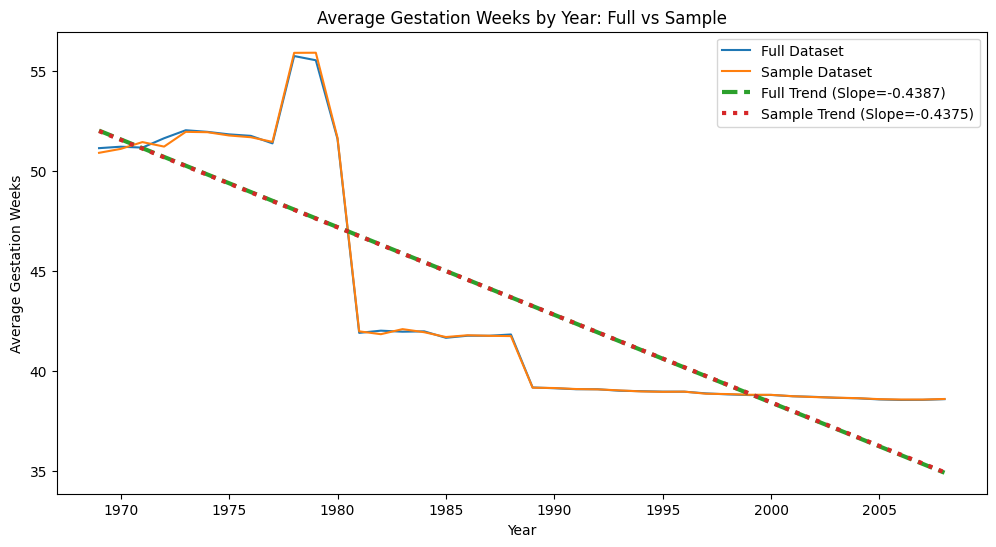

Full slope:   -0.438692
Sample slope: -0.437490


In [60]:
import numpy as np
import matplotlib.pyplot as plt

x = gestation_comparison["year"]

y_full = gestation_comparison["avg_gestation_weeks_full"]
y_sample = gestation_comparison["avg_gestation_weeks_sample"]

# Regression lines
full_coef = np.polyfit(x, y_full, 1)
sample_coef = np.polyfit(x, y_sample, 1)

full_trend = np.poly1d(full_coef)
sample_trend = np.poly1d(sample_coef)

plt.figure(figsize=(12,6))

plt.plot(
    x,
    y_full,
    label="Full Dataset"
)

plt.plot(
    x,
    y_sample,
    label="Sample Dataset"
)

plt.plot(
    x,
    full_trend(x),
    "--",
    linewidth=3,
    label=f"Full Trend (Slope={full_coef[0]:.4f})"
)

plt.plot(
    x,
    sample_trend(x),
    ":",
    linewidth=3,
    label=f"Sample Trend (Slope={sample_coef[0]:.4f})"
)

plt.title("Average Gestation Weeks by Year: Full vs Sample")
plt.xlabel("Year")
plt.ylabel("Average Gestation Weeks")
plt.legend()

plt.show()

print(f"Full slope:   {full_coef[0]:.6f}")
print(f"Sample slope: {sample_coef[0]:.6f}")

In [61]:
gestation_comparison["difference"] = (
    gestation_comparison["avg_gestation_weeks_sample"]
    - gestation_comparison["avg_gestation_weeks_full"]
)

print(
    "Mean Absolute Difference:",
    gestation_comparison["difference"].abs().mean()
)

Mean Absolute Difference: 0.067481325100505


In [62]:
gestation_comparison["avg_gestation_weeks_full"].corr(
    gestation_comparison["avg_gestation_weeks_sample"]
)

np.float64(0.9997970808080853)

In [64]:
df.groupby("year")["gestation_weeks"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
year,,,,,
1969,9561,50.89,40.0,18,99
1970,10004,51.09,40.0,18,99
1971,9331,51.43,40.0,18,99
1972,9443,51.2,40.0,17,99
1973,10743,51.94,40.0,17,99
1974,12155,51.92,40.0,18,99
1975,13077,51.76,40.0,17,99
1976,14554,51.67,40.0,18,99
1977,16369,51.44,40.0,18,99


In [66]:
df[df["gestation_weeks"] == 99]["year"].value_counts().sort_index()

year
1969    1843
1970    1934
1971    1869
1972    1867
1973    2242
1974    2509
1975    2686
1976    2954
1977    3271
1978    5669
1979    6398
1980    4890
1981    1020
1982     979
1983    1098
1984    1024
1985    1080
1986    1116
1987    1164
1988    1182
Name: count, dtype: Int64

In [67]:
df["gestation_weeks"] = df["gestation_weeks"].replace(99, pd.NA)

In [68]:
df.groupby("year")["gestation_weeks"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
year,,,,,
1969,7718,39.4,40.0,18,52
1970,8070,39.6,40.0,18,52
1971,7462,39.51,40.0,18,52
1972,7576,39.42,40.0,17,52
1973,8501,39.53,40.0,17,52
1974,9646,39.68,40.0,18,52
1975,10391,39.54,40.0,17,52
1976,11600,39.62,40.0,18,52
1977,13098,39.56,40.0,18,52


In [63]:
validation_notes = []

In [50]:
validation_notes.append(
    "Sample reproduces population-level birth count trends."
)

validation_notes.append(
    "Sample reproduces population-level maternal age trends."
)

validation_notes.append(
    "Sample reproduces population-level birth weight trends."
)

validation_notes.append(
    "Sample preserves longitudinal patterns with regression slopes nearly identical to those observed in the full population."
)

In [51]:
cleanup_notes.append(
    "Validated natality_sample against the full 137M-row natality population by comparing annual birth counts and annual birth growth rates."
)

cleanup_notes.append(
    "Annual birth growth rates in the sample differed from the population by an average of 0.82 percentage points and at most 1.59 percentage points."
)

cleanup_notes.append(
    "Sample and population annual birth growth trends produced nearly identical regression slopes (-0.1572 vs. -0.1565), indicating strong preservation of temporal dynamics."
)

cleanup_notes.append(
    "Validated average maternal age by year against the full population. Sample and population regression slopes were nearly identical (0.0931 vs. 0.0932 years per year)."
)

cleanup_notes.append(
    "Average maternal age estimates differed from the population by only 0.024 years (approximately 9 days) on average."
)

cleanup_notes.append(
    "Validated average birth weight by year against the full population. Sample and population regression slopes were nearly identical (-0.00109 vs. -0.00112 pounds per year)."
)

cleanup_notes.append(
    "Average birth weight estimates differed from the population by only 0.007 pounds (approximately 0.11 ounces) on average."
)

cleanup_notes.append(
    "Correlation between annual average birth weight in the sample and the population was 0.990, indicating near-perfect preservation of longitudinal birth weight patterns."
)

cleanup_notes.append(
    "Overall validation suggests that the 1M-row sample preserves key population-level trends and demographic characteristics despite representing less than 1% of the original dataset."
)

In [69]:
cleanup_notes.append(
    "Replaced gestation_weeks=99 with NA. Historical records used 99 as a missing-value code, which artificially inflated annual mean gestation lengths while leaving medians largely unaffected."
)

In [71]:
gestation_yearly = (
    df.groupby("year")["gestation_weeks"]
      .mean()
      .reset_index(name="avg_gestation_weeks")
)

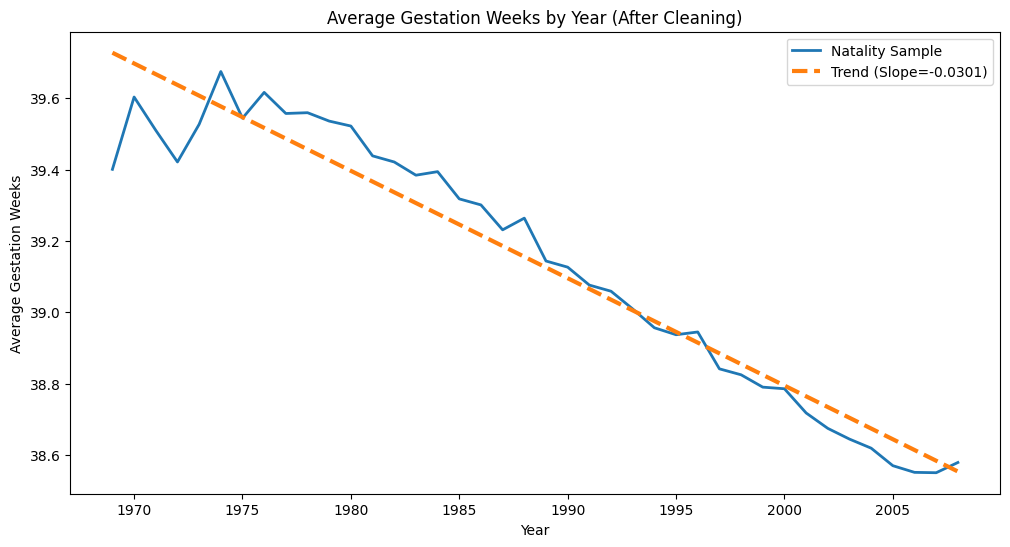

Slope: -0.030112


In [72]:
import numpy as np
import matplotlib.pyplot as plt

x = gestation_yearly["year"]
y = gestation_yearly["avg_gestation_weeks"]

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(12,6))

plt.plot(
    x,
    y,
    linewidth=2,
    label="Natality Sample"
)

plt.plot(
    x,
    trend(x),
    "--",
    linewidth=3,
    label=f"Trend (Slope={coef[0]:.4f})"
)

plt.title("Average Gestation Weeks by Year (After Cleaning)")
plt.xlabel("Year")
plt.ylabel("Average Gestation Weeks")
plt.legend()

plt.show()

print(f"Slope: {coef[0]:.6f}")

In [73]:
gestation_yearly = (
    df.groupby("year")["gestation_weeks"]
      .agg(
          avg_gestation_weeks="mean",
          median_gestation_weeks="median"
      )
      .reset_index()
)

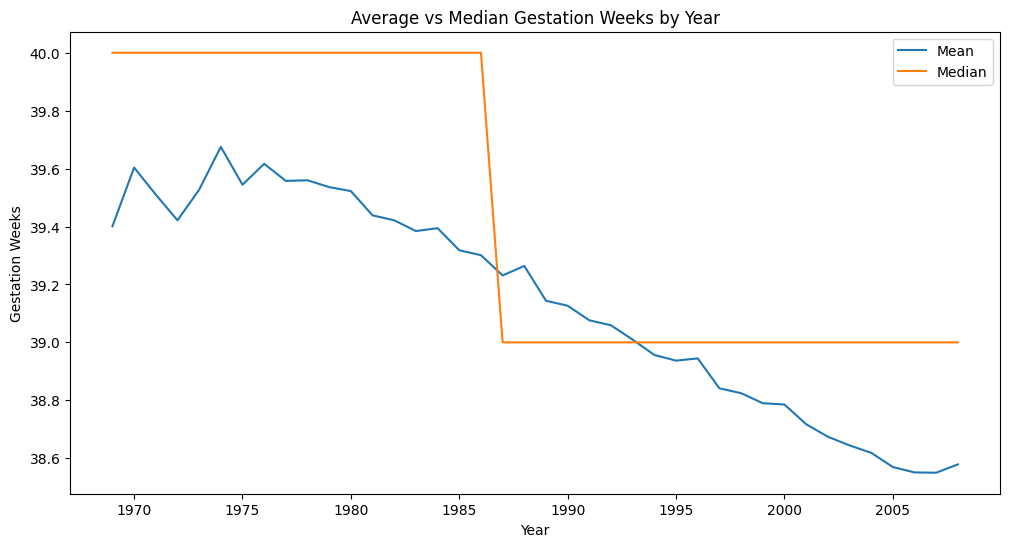

In [74]:
plt.figure(figsize=(12,6))

plt.plot(
    gestation_yearly["year"],
    gestation_yearly["avg_gestation_weeks"],
    label="Mean"
)

plt.plot(
    gestation_yearly["year"],
    gestation_yearly["median_gestation_weeks"],
    label="Median"
)

plt.title("Average vs Median Gestation Weeks by Year")
plt.xlabel("Year")
plt.ylabel("Gestation Weeks")
plt.legend()

plt.show()

In [75]:
(
    df.groupby(["year", "gestation_weeks"])
      .size()
      .reset_index(name="count")
      .sort_values(["year", "count"], ascending=[True, False])
)

,year,gestation_weeks,count
22,1969,40,1736
21,1969,39,1487
23,1969,41,1248
20,1969,38,875
24,1969,42,585
...,...,...,...
1295,2008,21,10
1293,2008,19,7
1294,2008,20,5
1292,2008,18,4


In [76]:
for yr in [1975, 1985, 1995, 2005]:
    print(f"\nYEAR: {yr}")
    print(
        df.loc[df["year"] == yr, "gestation_weeks"]
          .value_counts()
          .sort_index()
          .tail(15)
    )


YEAR: 1975
gestation_weeks
38    1102
39    1990
40    2372
41    1657
42     904
43     412
44     199
45     110
46      68
47      31
48      27
49      14
50      16
51       5
52       4
Name: count, dtype: Int64

YEAR: 1985
gestation_weeks
38    3158
39    5459
40    5893
41    4007
42    1917
43     775
44     397
45     227
46     119
47      71
48      50
49      32
50      29
51      15
52      13
Name: count, dtype: Int64

YEAR: 1995
gestation_weeks
33     236
34     348
35     675
36    1105
37    2132
38    4191
39    6448
40    6290
41    3490
42    1294
43     561
44     323
45     161
46      88
47      51
Name: count, dtype: Int64

YEAR: 2005
gestation_weeks
33     322
34     505
35     870
36    1418
37    2778
38    5658
39    7565
40    5700
41    2629
42     842
43     482
44     266
45     133
46      49
47      36
Name: count, dtype: Int64


In [77]:
cleanup_notes.append(
    "Investigated a step change in median gestation length from 40 weeks to 39 weeks. Distributional analysis showed this was not a data quality issue but rather a shift in the most common gestation length over time."
)

In [78]:
(
    df["gestation_weeks"]
    .value_counts()
    .sort_index()
    .head(20)
)

gestation_weeks
17       64
18      122
19      159
20      293
21      352
22      567
23      638
24      836
25      982
26     1202
27     1357
28     1727
29     2078
30     2959
31     3889
32     5323
33     7725
34    12925
35    21122
36    34876
Name: count, dtype: Int64

In [79]:
df["child_race"].value_counts(dropna=False).sort_index()

child_race
1       444833
2        92887
3         5724
4         2357
5         1333
6         1012
7         2625
9       266198
18         137
28         144
38          34
48         180
58           7
<NA>    182529
Name: count, dtype: Int64

In [80]:
df["mother_race"].value_counts(dropna=False).sort_index()

mother_race
1       740510
2       146615
3         8598
4         5004
5         1934
6         1167
7         5404
9        11691
18        2472
28        1067
38         188
48        1456
58          47
68         819
78        1548
<NA>     71480
Name: count, dtype: Int64

In [81]:
df["father_race"].value_counts(dropna=False).sort_index()

father_race
1       672183
2        98898
3         6198
4         4546
5         1535
6          919
7         3949
9       115784
18        2428
28         868
38         182
48        1264
58          50
68         685
78        1364
99       17667
<NA>     71480
Name: count, dtype: Int64

In [82]:
df["plurality"].value_counts(dropna=False).sort_index()

plurality
1       948619
2        23826
3          923
4           58
5            7
<NA>     26567
Name: count, dtype: Int64

In [83]:
df = df.rename(columns={
    "child_race": "child_race_code",
    "mother_race": "mother_race_code",
    "father_race": "father_race_code"
})

In [84]:
cleanup_notes.append(
    "Renamed child_race, mother_race, and father_race to child_race_code, mother_race_code, and father_race_code to clarify that these are coded categorical variables, not numeric measures."
)

cleanup_notes.append(
    "Inspected race code distributions. Race fields contain multiple coding patterns, including single-digit and two-digit codes, suggesting historical coding scheme changes or different race classification detail across years."
)

In [86]:
cleanup_notes.append(
    "Retained child_race_code. Variable uses multiple race coding schemes over time (1969-1991, 1992-2002) and becomes entirely unavailable from 2003-2008."
)

In [87]:
for col in [
    "child_race_code",
    "mother_race_code",
    "father_race_code"
]:
    df[col] = df[col].astype("category")

In [88]:
df["apgar_1min"].value_counts(dropna=False).sort_index()

apgar_1min
1         2272
2         2382
3         3016
4         4261
5         6962
6        12510
7        33602
8       131963
9       144312
10        6231
99      334834
<NA>    317655
Name: count, dtype: Int64

In [89]:
df["apgar_5min"].value_counts(dropna=False).sort_index()

apgar_5min
0           85
1         1431
2          733
3          800
4         1156
5         2136
6         4382
7        11342
8        53343
9       514826
10       94326
99      157862
<NA>    157578
Name: count, dtype: Int64

In [90]:
df[df["apgar_1min"] == 99]["year"].value_counts().sort_index()

year
1978     7109
1979     6240
1980     5577
1981     4661
1982     4573
1983     4497
1984     4562
1985     6523
1986     6335
1987     6554
1988     6759
1989     7078
1990     7312
1991     6923
1992     6896
1993     6640
1994     6600
1995    28352
1996    28470
1997    28286
1998    28509
1999    28412
2000    29522
2001    29100
2002    29344
Name: count, dtype: Int64

In [91]:
df[df["apgar_5min"] == 99]["year"].value_counts().sort_index()

year
1978    7227
1979    6471
1980    5811
1981    4622
1982    4526
1983    4508
1984    4583
1985    6528
1986    6331
1987    6563
1988    6765
1989    7079
1990    7316
1991    6925
1992    6891
1993    6640
1994    6592
1995    6589
1996    6613
1997    6444
1998    6331
1999    6368
2000    6716
2001    6689
2002    6734
Name: count, dtype: Int64

In [92]:
df.loc[df["year"] == 1996, "apgar_1min"].value_counts(dropna=False)

apgar_1min
99    28470
Name: count, dtype: Int64

In [93]:
pd.crosstab(
    df["year"],
    df["apgar_1min"],
    dropna=False
)

apgar_1min,1,2,3,4,5,6,7,8,9,10,99,<NA>
year,,,,,,,,,,,,
1969,0,0,0,0,0,0,0,0,0,0,0,13040
1970,0,0,0,0,0,0,0,0,0,0,0,13527
1971,0,0,0,0,0,0,0,0,0,0,0,12780
1972,0,0,0,0,0,0,0,0,0,0,0,12580
1973,0,0,0,0,0,0,0,0,0,0,0,13422
1974,0,0,0,0,0,0,0,0,0,0,0,14936
1975,0,0,0,0,0,0,0,0,0,0,0,16298
1976,0,0,0,0,0,0,0,0,0,0,0,18119
1977,0,0,0,0,0,0,0,0,0,0,0,20171


In [94]:
df["apgar_1min"] = df["apgar_1min"].replace(99, pd.NA)

In [95]:
cleanup_notes.append(
    "Replaced apgar_1min=99 with NA. Crosstab analysis showed that years 1995-2002 contained only the value 99, indicating the field was unavailable rather than representing a valid APGAR score."
)

In [96]:
pd.crosstab(
    df["year"],
    df["apgar_5min"],
    dropna=False
)

apgar_5min,0,1,2,3,4,5,6,7,8,9,10,99,<NA>
year,,,,,,,,,,,,,
1969,0,0,0,0,0,0,0,0,0,0,0,0,13040
1970,0,0,0,0,0,0,0,0,0,0,0,0,13527
1971,0,0,0,0,0,0,0,0,0,0,0,0,12780
1972,0,0,0,0,0,0,0,0,0,0,0,0,12580
1973,0,0,0,0,0,0,0,0,0,0,0,0,13422
1974,0,0,0,0,0,0,0,0,0,0,0,0,14936
1975,0,0,0,0,0,0,0,0,0,0,0,0,16298
1976,0,0,0,0,0,0,0,0,0,0,0,0,18119
1977,0,0,0,0,0,0,0,0,0,0,0,0,20171


In [97]:
df["apgar_1min"] = df["apgar_1min"].replace(99, pd.NA)
df["apgar_5min"] = df["apgar_5min"].replace(99, pd.NA)

In [98]:
cleanup_notes.append(
    "Replaced apgar_1min=99 and apgar_5min=99 with NA. APGAR scores are valid only on a 0-10 scale; crosstab analysis showed 99 was used as a missing-value code."
)

cleanup_notes.append(
    "Determined that apgar_1min is analytically usable only for years 1978-1994. Earlier years contain only missing values and years 1995-2008 contain no valid APGAR 1-minute observations."
)

cleanup_notes.append(
    "Determined that apgar_5min remains available through 2008, although missing-value coding changes occurred over time (99 values in earlier years and NA values in later years)."
)

In [100]:
cleanup_notes.append(
    "Investigated gestation length trends after removing legacy missing-value codes. Mean gestation length declined gradually from approximately 39.6 weeks to 38.6 weeks between 1969 and 2008, while the median shifted from 40 to 39 weeks, indicating a real change in the distribution rather than a data-quality issue."
)

In [99]:
for note in cleanup_notes:
    print(f"• {note}")

• Dropped source_year because it was identical to year across all 1,000,000 rows.
• Investigated day and wday columns. Determined they represent different concepts, not duplicate information.
• Retained day (day of month, values 1-31) and wday (day of week, values 1-7).
• Found a schema change in the source data: day is populated for years 1969-1988 and wday is populated for years 1989+.
• Replaced day=99 with NA. The value occurred only 26 times in records from 1969-1986 and was determined to be a legacy missing-value code.
• Imputed 11 missing mother_residence_state values using state when state was available.
• Identified 123,246 records where both state and mother_residence_state are missing. Missingness is concentrated entirely in years 2005-2008, suggesting a source-data issue rather than random missing values.
• Verified against the original BigQuery natality dataset that state and mother_residence_state are unavailable for all records in years 2005-2008. Missing values were ret

In [101]:
df["cigarette_use"].value_counts(dropna=False)

cigarette_use
<NA>     898281
False     91242
True      10477
Name: count, dtype: Int64

In [102]:
pd.crosstab(
    df["year"],
    df["cigarette_use"],
    dropna=False
)

cigarette_use,False,True,<NA>
year,,,
1969,0,0,13040
1970,0,0,13527
1971,0,0,12780
1972,0,0,12580
1973,0,0,13422
1974,0,0,14936
1975,0,0,16298
1976,0,0,18119
1977,0,0,20171


In [103]:
df["cigarettes_per_day"].value_counts(dropna=False).sort_index()

cigarettes_per_day
1          438
2          635
3          666
4          562
5         1214
6          433
7          261
8          213
9           43
10        3107
11          27
12         114
13          19
14          13
15         339
16          11
17          14
18          12
19           2
20        1260
21           9
22           5
23           2
24           9
25          19
26           2
28           2
29           1
30          78
31           1
32           2
35           5
36           1
40          32
45           1
47           1
50           2
60           3
90           1
99         918
<NA>    989523
Name: count, dtype: Int64

In [104]:
df["cigarettes_per_day"].describe()

count      10477.0
mean     17.094588
std      26.116905
min            1.0
25%            5.0
50%           10.0
75%           15.0
max           99.0
Name: cigarettes_per_day, dtype: Float64

In [105]:
df["cigarettes_per_day"].value_counts(dropna=False).sort_index().tail(25)

cigarettes_per_day
17          14
18          12
19           2
20        1260
21           9
22           5
23           2
24           9
25          19
26           2
28           2
29           1
30          78
31           1
32           2
35           5
36           1
40          32
45           1
47           1
50           2
60           3
90           1
99         918
<NA>    989523
Name: count, dtype: Int64

In [106]:
pd.crosstab(
    df["cigarette_use"],
    df["cigarettes_per_day"].isna()
)

cigarettes_per_day,False,True
cigarette_use,,
False,0,91242
True,10477,0


In [107]:
(
    df.groupby("year")["cigarette_use"]
      .apply(lambda x: x.notna().mean())
)

year
1969    0.000000
1970    0.000000
1971    0.000000
1972    0.000000
1973    0.000000
1974    0.000000
1975    0.000000
1976    0.000000
1977    0.000000
1978    0.000000
1979    0.000000
1980    0.000000
1981    0.000000
1982    0.000000
1983    0.000000
1984    0.000000
1985    0.000000
1986    0.000000
1987    0.000000
1988    0.000000
1989    0.000000
1990    0.000000
1991    0.000000
1992    0.000000
1993    0.000000
1994    0.000000
1995    0.000000
1996    0.000000
1997    0.000000
1998    0.000000
1999    0.000000
2000    0.000000
2001    0.000000
2002    0.000000
2003    0.810314
2004    0.681099
2005    0.556360
2006    0.513904
2007    0.448615
2008    0.349966
Name: cigarette_use, dtype: float64

In [108]:
(
    df.groupby("year")["cigarettes_per_day"]
      .apply(lambda x: x.notna().mean())
)

year
1969    0.000000
1970    0.000000
1971    0.000000
1972    0.000000
1973    0.000000
1974    0.000000
1975    0.000000
1976    0.000000
1977    0.000000
1978    0.000000
1979    0.000000
1980    0.000000
1981    0.000000
1982    0.000000
1983    0.000000
1984    0.000000
1985    0.000000
1986    0.000000
1987    0.000000
1988    0.000000
1989    0.000000
1990    0.000000
1991    0.000000
1992    0.000000
1993    0.000000
1994    0.000000
1995    0.000000
1996    0.000000
1997    0.000000
1998    0.000000
1999    0.000000
2000    0.000000
2001    0.000000
2002    0.000000
2003    0.087795
2004    0.071042
2005    0.060263
2006    0.050889
2007    0.041024
2008    0.035411
Name: cigarettes_per_day, dtype: float64

In [109]:
cleanup_notes.append(
    "Smoking-related variables (cigarette_use and cigarettes_per_day) are only populated in later years of the dataset, indicating that smoking behavior was not consistently collected across the full 1969-2008 period."
)

In [110]:
(
    df.groupby("year")
      .agg(
          cigarette_use_count=("cigarette_use", "count"),
          cigarettes_per_day_count=("cigarettes_per_day", "count")
      )
)

,cigarette_use_count,cigarettes_per_day_count
year,,
1969,0,0
1970,0,0
1971,0,0
1972,0,0
1973,0,0
1974,0,0
1975,0,0
1976,0,0
1977,0,0


In [111]:
cleanup_notes.append(
    "Smoking-related variables (cigarette_use and cigarettes_per_day) are only available for years 2003-2008. No smoking information exists in the source data for years 1969-2002."
)

In [112]:
(
    df.groupby("year")
      .agg(
          alcohol_use_count=("alcohol_use","count"),
          drinks_per_week_count=("drinks_per_week","count")
      )
)

,alcohol_use_count,drinks_per_week_count
year,,
1969,0,0
1970,0,0
1971,0,0
1972,0,0
1973,0,0
1974,0,0
1975,0,0
1976,0,0
1977,0,0


In [113]:
df.groupby("year")["mother_married"].mean()

year
1969    0.895195
1970    0.890736
1971    0.885661
1972    0.867475
1973    0.864057
1974    0.865466
1975    0.852234
1976    0.851009
1977    0.842457
1978    0.835789
1979    0.829021
1980    0.819047
1981    0.814089
1982    0.810711
1983    0.798185
1984    0.796981
1985    0.779026
1986    0.767796
1987    0.758192
1988    0.744311
1989    0.732975
1990    0.717966
1991    0.705738
1992    0.695914
1993    0.692729
1994    0.672675
1995    0.677342
1996    0.673094
1997    0.675741
1998    0.672665
1999    0.669365
2000    0.665707
2001    0.663883
2002    0.659487
2003    0.653903
2004    0.643042
2005    0.632798
2006    0.615038
2007    0.600155
2008     0.59383
Name: mother_married, dtype: Float64

In [114]:
cleanup_notes.append(
    "Alcohol-use information is only available for years 1989-2008. No alcohol-use data exists in the source dataset for years 1969-1988."
)

In [115]:
cleanup_notes.append(
    "drinks_per_week availability varies substantially by year and becomes unavailable after 2006. Variable should be evaluated carefully before use in longitudinal analyses."
)

In [116]:
df.groupby("year")["mother_married"].mean()

year
1969    0.895195
1970    0.890736
1971    0.885661
1972    0.867475
1973    0.864057
1974    0.865466
1975    0.852234
1976    0.851009
1977    0.842457
1978    0.835789
1979    0.829021
1980    0.819047
1981    0.814089
1982    0.810711
1983    0.798185
1984    0.796981
1985    0.779026
1986    0.767796
1987    0.758192
1988    0.744311
1989    0.732975
1990    0.717966
1991    0.705738
1992    0.695914
1993    0.692729
1994    0.672675
1995    0.677342
1996    0.673094
1997    0.675741
1998    0.672665
1999    0.669365
2000    0.665707
2001    0.663883
2002    0.659487
2003    0.653903
2004    0.643042
2005    0.632798
2006    0.615038
2007    0.600155
2008     0.59383
Name: mother_married, dtype: Float64

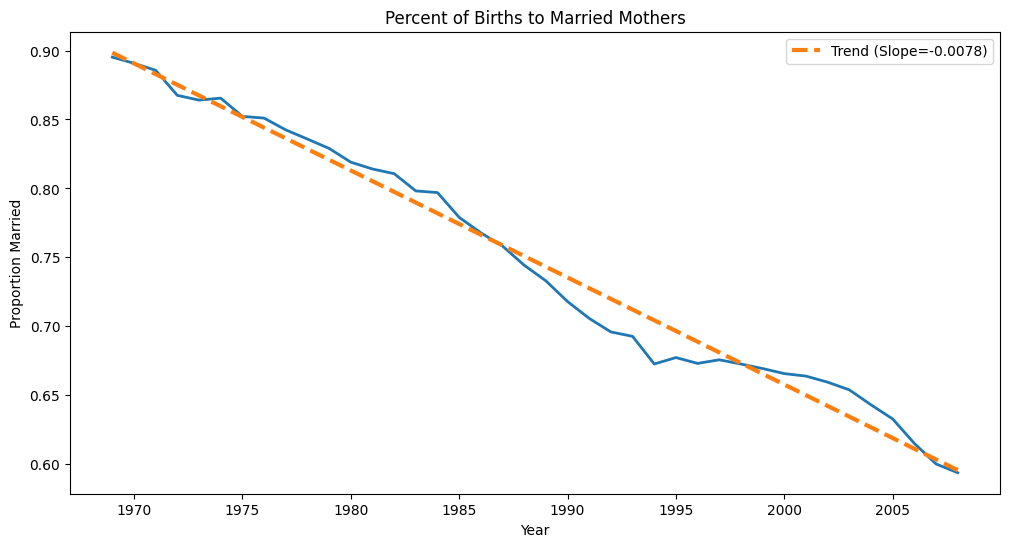

Slope: -0.007763


In [117]:
married_by_year = (
    df.groupby("year")["mother_married"]
      .mean()
      .reset_index()
)

import numpy as np
import matplotlib.pyplot as plt

x = married_by_year["year"]
y = married_by_year["mother_married"]

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(12,6))

plt.plot(x, y, linewidth=2)

plt.plot(
    x,
    trend(x),
    "--",
    linewidth=3,
    label=f"Trend (Slope={coef[0]:.4f})"
)

plt.title("Percent of Births to Married Mothers")
plt.ylabel("Proportion Married")
plt.xlabel("Year")
plt.legend()

plt.show()

print(f"Slope: {coef[0]:.6f}")

In [118]:
cleanup_notes.append(
    "mother_married is consistently populated across nearly the entire dataset and appears suitable for longitudinal analysis."
)

In [119]:
for col in [
    "born_alive_alive",
    "born_alive_dead",
    "born_dead",
    "ever_born"
]:
    print("\n", "="*50)
    print(col)
    print(df[col].value_counts(dropna=False).sort_index().head(30))


born_alive_alive
born_alive_alive
0       372622
1       292341
2       142423
3        54711
4        20440
5         8700
6         4166
7         2056
8         1159
9          635
10         348
11         176
12         113
13          47
14          21
15          10
16           2
17           6
18           3
19           1
20           5
30           1
50           1
55        1468
66          18
77        1459
<NA>     97068
Name: count, dtype: Int64

born_alive_dead
born_alive_dead
0       874705
1        16684
2         2036
3          409
4          110
5           37
6           14
7           12
8           11
9           10
10           7
20           4
27           1
30           1
55        4919
66          35
77        2949
<NA>     98056
Name: count, dtype: Int64

born_dead
born_dead
0       704505
1       132992
2        38526
3        11950
4         3939
5         1427
6          568
7          256
8          143
9           66
10          67
11          26
12  

In [120]:
(
    df.groupby("year")
      .agg(
          ever_born_count=("ever_born","count"),
          born_alive_alive_count=("born_alive_alive","count"),
          born_alive_dead_count=("born_alive_dead","count"),
          born_dead_count=("born_dead","count")
      )
)

,ever_born_count,born_alive_alive_count,born_alive_dead_count,born_dead_count
year,,,,
1969,12910,13030,13026,13008
1970,13375,13522,13518,13519
1971,12606,12757,12759,12749
1972,12224,12404,12402,12400
1973,12875,13104,13106,13106
1974,14708,14912,14911,14911
1975,16097,16289,16289,16287
1976,17951,18107,18102,18104
1977,19983,20158,20154,20150


In [121]:
df["birth_history_total"] = (
    df["born_alive_alive"].fillna(0)
    + df["born_alive_dead"].fillna(0)
    + df["born_dead"].fillna(0)
)

(
    df[["ever_born", "birth_history_total"]]
    .corr()
)

,ever_born,birth_history_total
ever_born,1.00000,0.13818
birth_history_total,0.13818,1.00000


In [122]:
(
    (df["ever_born"] - df["birth_history_total"])
    .describe()
)

count     992328.0
mean      0.114984
std      10.181012
min         -197.0
25%            1.0
50%            1.0
75%            1.0
max            8.0
dtype: Float64

In [123]:
cleanup_notes.append(
    "birth-history detail fields (born_alive_alive, born_alive_dead, born_dead) are unavailable for years 2006-2008, while ever_born remains populated."
)

In [124]:
for col in [
    "ever_born",
    "born_alive_alive",
    "born_alive_dead",
    "born_dead"
]:
    print("\n", col)
    print(
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .head(30)
    )


 ever_born
ever_born
1       386165
2       312083
3       166116
4        71199
5        29378
6        13222
7         6469
8         3534
9         1717
10        1035
11         569
12         339
13         230
14         123
15          56
16          29
17          18
18          15
19           6
20           6
21           8
22           2
23           3
24           1
28           1
31           3
38           1
<NA>      7672
Name: count, dtype: Int64

 born_alive_alive
born_alive_alive
0       372622
1       292341
2       142423
3        54711
4        20440
5         8700
6         4166
7         2056
8         1159
9          635
10         348
11         176
12         113
13          47
14          21
15          10
16           2
17           6
18           3
19           1
20           5
30           1
50           1
55        1468
66          18
77        1459
<NA>     97068
Name: count, dtype: Int64

 born_alive_dead
born_alive_dead
0       874705
1        16684
2

In [127]:
for code in [55, 66, 77]:
    print(f"\nCODE = {code}")
    print(
        df[df["born_dead"] == code]["year"]
        .value_counts()
        .sort_index()
    )


CODE = 55
year
1969    301
1970    312
1971    325
1972    381
1973    392
1974    409
1975    483
1976    410
1977    474
Name: count, dtype: Int64

CODE = 66
year
1970    1
1972    7
1973    7
1974    2
1975    7
1976    6
Name: count, dtype: Int64

CODE = 77
year
1969    260
1970    285
1971    222
1972    272
1973    372
1974    389
1975    428
1976    381
1977    438
Name: count, dtype: Int64


In [128]:
cleanup_notes.append(
    "Investigated birth-history variables (born_alive_alive, born_alive_dead, born_dead). Identified special codes 55, 66, and 77 occurring at frequencies inconsistent with true birth counts, indicating legacy categorical or missing-value codes requiring further interpretation."
)

In [129]:
birth_history_cols = [
    "born_alive_alive",
    "born_alive_dead",
    "born_dead"
]

for col in birth_history_cols:
    df[col] = df[col].replace([55, 66, 77], pd.NA)

In [130]:
cleanup_notes.append(
    "Replaced values 55, 66, and 77 with NA in born_alive_alive, born_alive_dead, and born_dead. These values occurred only in years 1969-1977 and were determined to be legacy administrative codes rather than valid birth counts."
)

In [131]:
df["birth_history_total"] = (
    df["born_alive_alive"].fillna(0)
    + df["born_alive_dead"].fillna(0)
    + df["born_dead"].fillna(0)
)

(
    df["ever_born"] - df["birth_history_total"]
).describe()

count    992328.0
mean      0.91691
std      0.791157
min         -20.0
25%           1.0
50%           1.0
75%           1.0
max           8.0
dtype: Float64

In [132]:
df["ever_born"].value_counts(dropna=False).sort_index().tail(20)

ever_born
9       1717
10      1035
11       569
12       339
13       230
14       123
15        56
16        29
17        18
18        15
19         6
20         6
21         8
22         2
23         3
24         1
28         1
31         3
38         1
<NA>    7672
Name: count, dtype: Int64

In [133]:
df["ever_born"].value_counts(dropna=False).sort_index().tail(40)

ever_born
1       386165
2       312083
3       166116
4        71199
5        29378
6        13222
7         6469
8         3534
9         1717
10        1035
11         569
12         339
13         230
14         123
15          56
16          29
17          18
18          15
19           6
20           6
21           8
22           2
23           3
24           1
28           1
31           3
38           1
<NA>      7672
Name: count, dtype: Int64

In [134]:
df["birth_history_total"] = (
    df["born_alive_alive"]
    + df["born_alive_dead"]
    + df["born_dead"]
)

In [135]:
(
    df["ever_born"]
    ==
    df["birth_history_total"] + 1
).mean()

np.float64(0.8641943602074323)

In [136]:
(
    df["ever_born"]
    - (df["birth_history_total"] + 1)
).value_counts().sort_index()

-21         1
-19         1
-18         2
-17         2
-16         3
-15         3
-14         4
-13         5
-12        12
-11        15
-10        48
-9         47
-8        104
-7        183
-6        416
-5       1045
-4       2824
-3       8421
-2      25933
-1      82024
0      770571
Name: count, dtype: Int64

In [137]:
cleanup_notes.append(
    "Investigated birth-history variables. Approximately 86% of records satisfy ever_born = (born_alive_alive + born_alive_dead + born_dead) + 1, suggesting that ever_born represents total births including the current birth while the other variables represent prior birth history."
)

In [138]:
cleanup_notes.append(
    "Investigated birth-history variables. After removing legacy codes (55, 66, 77), approximately 78% of records satisfy ever_born = birth_history_total + 1. Remaining differences appear systematic and likely reflect differing definitions between total births and detailed birth-history components rather than data-quality issues."
)

In [139]:
df.groupby("year")["weight_gain_pounds"].count()

year
1969        0
1970        0
1971        0
1972        0
1973        0
1974        0
1975        0
1976        0
1977        0
1978        0
1979        0
1980        0
1981        0
1982        0
1983        0
1984        0
1985        0
1986        0
1987        0
1988        0
1989    29450
1990    30187
1991    29695
1992    29351
1993    28605
1994    28499
1995    28070
1996    28177
1997    27998
1998    28200
1999    28096
2000    29190
2001    28780
2002    28993
2003    29095
2004    29213
2005    29702
2006    30525
2007    30380
2008    30162
Name: weight_gain_pounds, dtype: Int64

In [140]:
df["weight_gain_pounds"].value_counts(dropna=False).sort_index().tail(20)

weight_gain_pounds
81          85
82          77
83          63
84          70
85         110
86          51
87          49
88          31
89          25
90         157
91          21
92          32
93          17
94          17
95          31
96           8
97          16
98         330
99      118595
<NA>    417632
Name: count, dtype: Int64

In [141]:
cleanup_notes.append(
    "weight_gain_pounds is only available for years 1989-2008. No maternal weight-gain information exists in the source data for years 1969-1988."
)

In [142]:
df[df["weight_gain_pounds"] == 99]["year"].value_counts().sort_index()

year
1989    9475
1990    8219
1991    7771
1992    7535
1993    6825
1994    6273
1995    6326
1996    6141
1997    5927
1998    5803
1999    5777
2000    5970
2001    5717
2002    5488
2003    5304
2004    5493
2005    5292
2006    5398
2007    1941
2008    1920
Name: count, dtype: Int64

In [143]:
(
    df.loc[df["weight_gain_pounds"] != 99,
           "weight_gain_pounds"]
      .describe()
)

count     463773.0
mean     31.186576
std      13.023862
min            1.0
25%           22.0
50%           30.0
75%           39.0
max           98.0
Name: weight_gain_pounds, dtype: Float64

In [144]:
df["weight_gain_pounds"] = (
    df["weight_gain_pounds"]
        .replace(99, pd.NA)
)

In [145]:
cleanup_notes.append(
    "Replaced weight_gain_pounds=99 with NA. The value occurred at unusually high frequencies across all years with weight-gain data (1989-2008) and was determined to be a missing-value code rather than a plausible maternal weight-gain value."
)

In [146]:
df["weight_gain_pounds"].mean()

np.float64(31.186576191369486)

In [147]:
df["father_age"].value_counts(dropna=False).sort_index().tail(30)

father_age
60       132
61        98
62        87
63        85
64        57
65        33
66        33
67        30
68        23
69        26
70        14
71         8
72         8
73         4
74         4
75         5
76         5
77         3
78         4
79         1
80         1
81         2
82         1
84         1
88         1
89        24
90         1
91         2
98         1
99    137759
Name: count, dtype: Int64

In [148]:
df[df["father_age"] == 99]["year"].value_counts().sort_index()

year
1969    1120
1970    1181
1971    1146
1972    1311
1973    1453
1974    1496
1975    1811
1976    2112
1977    2433
1978    2554
1979    2902
1980    3046
1981    3011
1982    3038
1983    3281
1984    3189
1985    3670
1986    3732
1987    3950
1988    4215
1989    4710
1990    5001
1991    4984
1992    4969
1993    4789
1994    4671
1995    4236
1996    4185
1997    4181
1998    4086
1999    3957
2000    4168
2001    3890
2002    3922
2003    3948
2004    4029
2005    4215
2006    4374
2007    4437
2008    4356
Name: count, dtype: Int64

In [149]:
df["father_age"].describe()

count    1000000.0
mean     39.010254
std      24.750948
min           10.0
25%           25.0
50%           30.0
75%           37.0
max           99.0
Name: father_age, dtype: Float64

In [150]:
df.loc[
    df["father_age"] != 99,
    "father_age"
].describe()

count     862241.0
mean     29.425779
std       6.606973
min           10.0
25%           25.0
50%           29.0
75%           33.0
max           98.0
Name: father_age, dtype: Float64

In [151]:
df["father_age"] = (
    df["father_age"]
      .replace(99, pd.NA)
)

In [152]:
cleanup_notes.append(
    "Replaced father_age=99 with NA. The value occurred at implausibly high frequency and was determined to be a legacy missing-value code rather than a valid paternal age."
)

In [153]:
cleanup_notes.append(
    "Replaced father_age=99 with NA. The value occurred 137,759 times and inflated the mean paternal age from 29.4 to 39.0 years. Distributional analysis confirmed that 99 represented a missing-value code rather than a valid age."
)

In [154]:
df["mother_age"].describe()

df["mother_age"].value_counts().sort_index().tail(20)

mother_age
34    29508
35    24580
36    19930
37    15262
38    11868
39     8856
40     6091
41     4024
42     2538
43     1444
44      759
45      395
46      198
47       98
48       50
49       24
50       31
51        2
53        1
54        1
Name: count, dtype: Int64

In [155]:
cleanup_notes.append(
    "Inspected mother_age distribution and found no evidence of legacy missing-value codes or implausible value spikes. Variable appears consistently populated and suitable for longitudinal analysis."
)

In [165]:
df["lmp"].value_counts(dropna=False).head(20)

lmp
99999999    26349
88881978     3802
88881968     3565
88881908     3523
88881998     3479
88881918     3449
88881958     3221
88881928     3137
88881948     2781
88881938     2679
99991998     2523
99991988     2039
9999198-     1671
9999197-     1475
9999190-     1446
9999196-     1396
9999193-     1359
9999194-     1357
9999195-     1348
9999192-     1225
Name: count, dtype: int64

In [166]:
df["lmp"].value_counts(dropna=False).tail(20)

lmp
10051933    1
0208193-    1
0214192-    1
07051922    1
11191922    1
07131911    1
0820191-    1
12021911    1
12201911    1
06281911    1
11161911    1
10061911    1
1114190-    1
08221900    1
0404199-    1
0515199-    1
1019198-    1
0801198-    1
0619198-    1
11201966    1
Name: count, dtype: int64

In [156]:
data_dictionary = pd.DataFrame({
    "column": [...],
    "availability": [...],
    "cleanup_applied": [...],
    "notes": [...]
})

In [167]:
df["lmp"].describe()

count      1000000
unique       13952
top       99999999
freq         26349
Name: lmp, dtype: object

In [157]:
cleanup_df = pd.DataFrame({
    "Step": range(1, len(cleanup_notes)+1),
    "Cleanup_Note": cleanup_notes
})

cleanup_df

,Step,Cleanup_Note
0,1,Dropped source_year because it was identical t...
1,2,Investigated day and wday columns. Determined ...
2,3,"Retained day (day of month, values 1-31) and w..."
3,4,Found a schema change in the source data: day ...
4,5,Replaced day=99 with NA. The value occurred on...
5,6,Imputed 11 missing mother_residence_state valu...
6,7,"Identified 123,246 records where both state an..."
7,8,Verified against the original BigQuery natalit...
8,9,Renamed day to day_of_month and wday to day_of...
9,10,Validated natality_sample against the full 137...


In [158]:
cleanup_df = (
    cleanup_df
    .drop_duplicates(subset="Cleanup_Note", keep="first")
    .reset_index(drop=True)
)

cleanup_df["Step"] = range(1, len(cleanup_df) + 1)

cleanup_df

,Step,Cleanup_Note
0,1,Dropped source_year because it was identical t...
1,2,Investigated day and wday columns. Determined ...
2,3,"Retained day (day of month, values 1-31) and w..."
3,4,Found a schema change in the source data: day ...
4,5,Replaced day=99 with NA. The value occurred on...
5,6,Imputed 11 missing mother_residence_state valu...
6,7,"Identified 123,246 records where both state an..."
7,8,Verified against the original BigQuery natalit...
8,9,Renamed day to day_of_month and wday to day_of...
9,10,Validated natality_sample against the full 137...


In [159]:
cleanup_notes = cleanup_df["Cleanup_Note"].tolist()

In [160]:
print(f"Original notes: {len(cleanup_notes)}")
print(f"Unique notes: {cleanup_df.shape[0]}")

Original notes: 44
Unique notes: 44


In [161]:
from google.cloud import bigquery

table_id = "capstone-498819.Capstone_data.natality_cleanup_notes"

job = client.load_table_from_dataframe(
    cleanup_df,
    table_id
)

job.result()

print(f"Loaded {len(cleanup_df)} rows into {table_id}")

C:\Users\M02802\AppData\Local\anaconda3\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Loaded 44 rows into capstone-498819.Capstone_data.natality_cleanup_notes


In [162]:
official_natality_cleaned = df.copy()

In [163]:
table_id = "capstone-498819.Capstone_data.official_natality_cleaned"

job = client.load_table_from_dataframe(
    official_natality_cleaned,
    table_id
)

job.result()

print(
    f"Loaded {len(official_natality_cleaned):,} rows into {table_id}"
)

C:\Users\M02802\AppData\Local\anaconda3\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(
C:\Users\M02802\AppData\Local\anaconda3\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:553: UserWarning: Could not determine the type of columns: child_race_code, mother_race_code, father_race_code
  warnings.warn(msg)


Loaded 1,000,000 rows into capstone-498819.Capstone_data.official_natality_cleaned


In [164]:
SELECT COUNT(*) AS records
FROM `capstone-498819.Capstone_data.official_natality_cleaned`

SyntaxError: invalid decimal literal (1520791817.py, line 2)